In [2]:
from pathlib import Path

# Resolve repo root even if notebook is opened from a subdir.
repo_root = Path.cwd()
marker = Path('data_loader') / 'GetDataset_ISIC2018.py'
if not (repo_root / marker).exists():
    for parent in repo_root.parents:
        if (parent / marker).exists():
            repo_root = parent
            break
assert (repo_root / marker).exists(), 'Run this notebook inside the DconnNet repository.'
print('repo_root =', repo_root)

repo_root = /data1/suhohan/DconnNet


## Raw ISIC2018 Dataset: Include All Images + Plot 5 Pairs

This section builds a dataset over **all** available `data/ISIC2018_img/train/images/*.jpg` files (paired with `*_segmentation.png`),
then plots 5 `(image, label)` pairs for quick sanity-check visualization.


raw train pairs: 2594
plotting: ['ISIC_0000000.jpg', 'ISIC_0000001.jpg', 'ISIC_0000003.jpg', 'ISIC_0000004.jpg', 'ISIC_0000006.jpg']


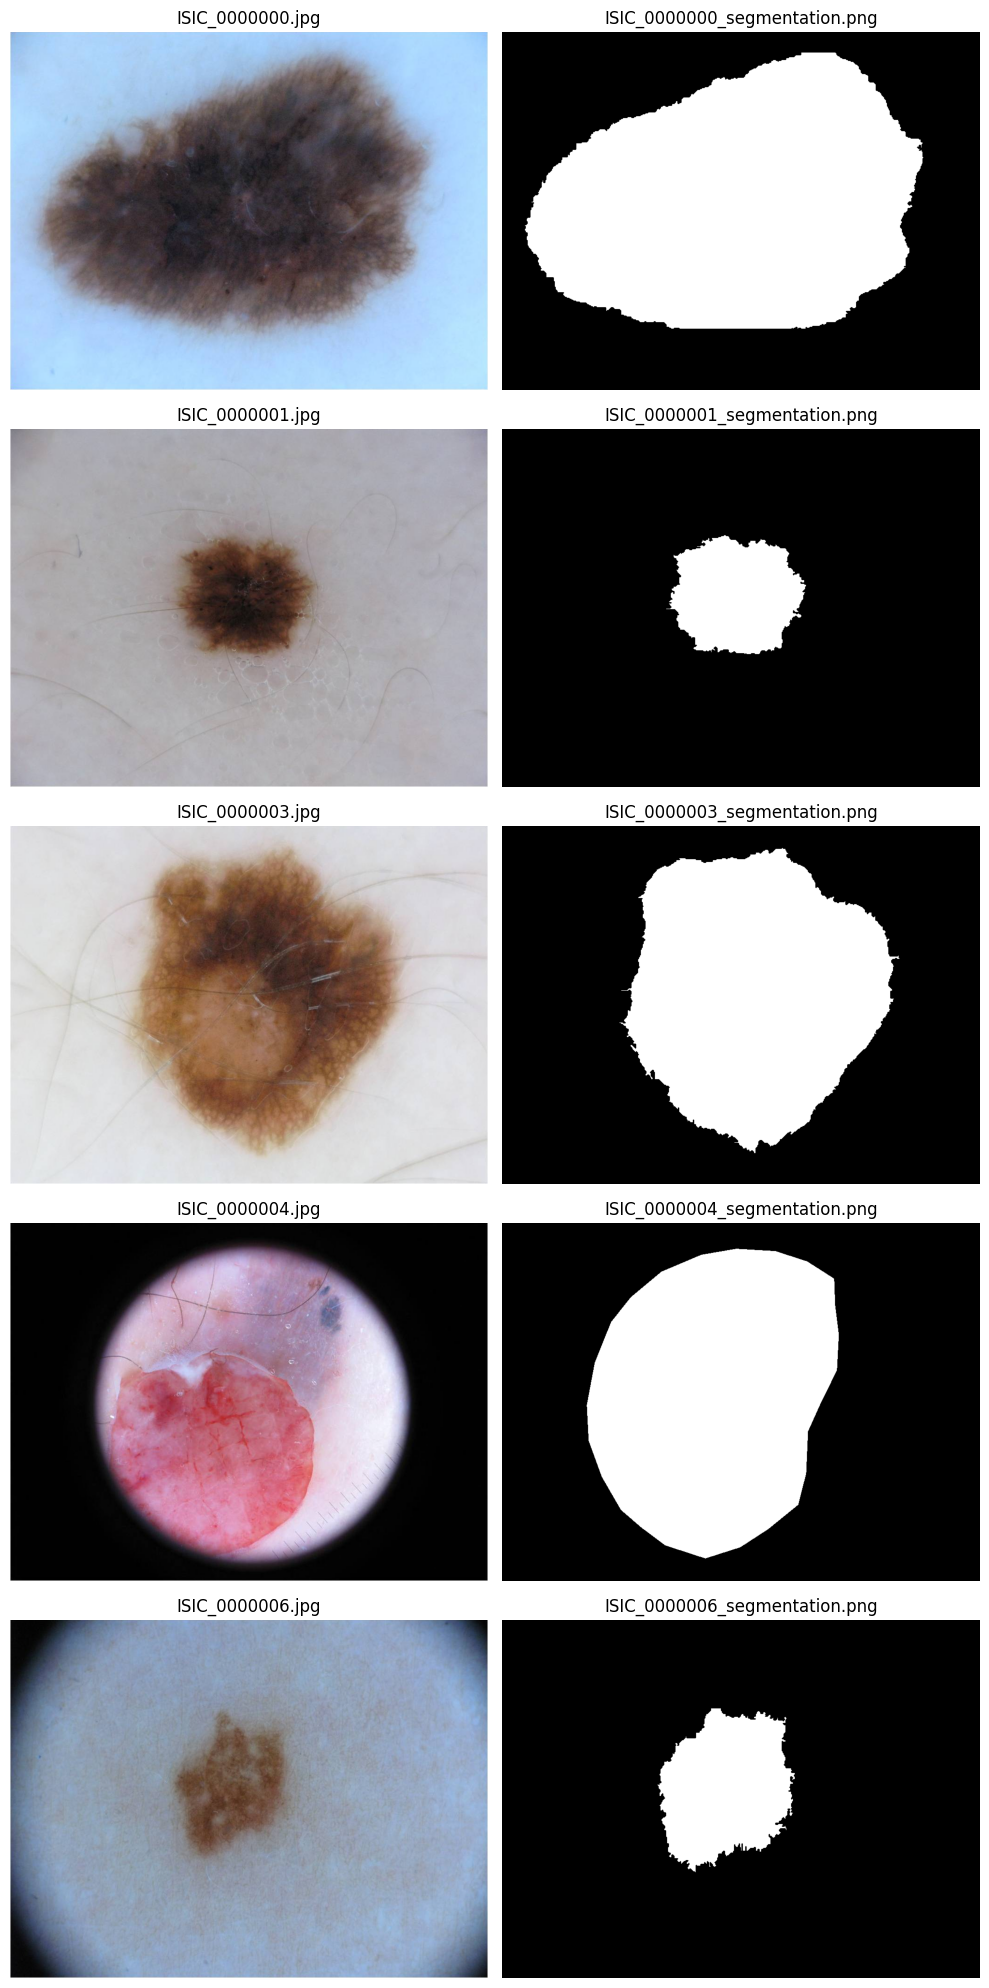

In [3]:
from dataclasses import dataclass
from typing import List
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


@dataclass(frozen=True)
class ISICPair:
    image_path: Path
    mask_path: Path


def collect_isic_pairs(split_root: Path) -> List[ISICPair]:
    img_dir = split_root / "images"
    mask_dir = split_root / "labels"
    assert img_dir.exists(), f"Missing: {img_dir}"
    assert mask_dir.exists(), f"Missing: {mask_dir}"

    pairs: List[ISICPair] = []
    for img_path in sorted(img_dir.glob("ISIC_*.jpg")):
        stem = img_path.stem
        mask_path = mask_dir / f"{stem}_segmentation.png"
        if mask_path.exists():
            pairs.append(ISICPair(image_path=img_path, mask_path=mask_path))
    return pairs


raw_dataset_root = repo_root / "data" / "ISIC2018_img"
if not (raw_dataset_root / "train" / "images").exists():
    raw_dataset_root = repo_root / "data" / "ISIC2018"
raw_train_root = raw_dataset_root / "train"
raw_pairs = collect_isic_pairs(raw_train_root)
assert len(raw_pairs) > 0, "No paired ISIC train samples found."
print("raw train pairs:", len(raw_pairs))

# Pick 5 samples (first 5 for determinism)
plot_pairs = raw_pairs[:5]
print("plotting:", [p.image_path.name for p in plot_pairs])

fig, axes = plt.subplots(len(plot_pairs), 2, figsize=(10, 4 * len(plot_pairs)))
if len(plot_pairs) == 1:
    axes = np.array([axes])

for i, pair in enumerate(plot_pairs):
    img = np.array(Image.open(pair.image_path).convert("RGB"))
    mask = np.array(Image.open(pair.mask_path).convert("L"))
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(pair.image_path.name)
    axes[i, 0].axis("off")
    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title(pair.mask_path.name)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [4]:
import shutil

# Cleanup is best-effort: skip if these variables were never created in this session.
for _name in ("tmp_dataset_root", "tmp_list_dir"):
    _path = globals().get(_name)
    if _path is not None:
        shutil.rmtree(_path, ignore_errors=True)
print('Cleanup done (or skipped).')

Cleanup done (or skipped).
